In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('HrForMl.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Absences,Year,Month,Day,Hire_month_name,Hire_day_name,Salary_label,Age,Tenure_years,Days_since_review
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,1,2011,7,5,July,Tuesday,Medium Salary,42,15,2781
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,17,2015,3,30,March,Monday,High Salary,51,11,3839
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,3,2011,7,5,July,Tuesday,Medium Salary,37,15,5219
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,15,2008,1,7,January,Monday,Medium Salary,37,18,2795
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,2,2011,7,11,July,Monday,Medium Salary,37,15,3862


## F. Machine Learning

### 1. Linear Regression (Supervised Regression)
Problem Question: Can we predict an employee's Salary based on their age, tenure, satisfaction, and project involvement?

In [3]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Gender', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences', 'Year', 'Month', 'Day', 'Hire_month_name', 'Hire_day_name',
       'Salary_label', 'Age', 'Tenure_years', 'Days_since_review'],
      dtype='str')

In [4]:
df['PerfScoreID'].unique()

array([4, 3, 2, 1])

In [5]:
df['DeptID'].unique()

array([5, 3, 4, 1, 6, 2])

In [6]:
cor_data = df[['Salary', 'GenderID', 'DeptID', 'Termd', 'PositionID', 'PerfScoreID', 'EngagementSurvey',
                'EmpSatisfaction', 'SpecialProjectsCount', 'Absences', 'DaysLateLast30', 'Age', 
                'Tenure_years']].corr()
cor_data

,Salary,GenderID,DeptID,Termd,PositionID,PerfScoreID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,Absences,DaysLateLast30,Age,Tenure_years
Salary,1.000000,0.056097,-0.448132,-0.093994,-0.130563,0.130903,0.064966,0.062718,0.508333,0.082382,-0.069443,0.096180,-0.122338
GenderID,0.056097,1.000000,-0.038838,-0.015741,-0.081612,-0.054915,-0.036276,-0.044603,0.087073,-0.004577,0.080329,-0.012922,-0.052543
DeptID,-0.448132,-0.038838,1.000000,0.065922,0.030294,-0.084811,-0.094940,0.031997,-0.785101,0.053308,0.124630,0.095390,0.266512
Termd,-0.093994,-0.015741,0.065922,1.000000,0.147042,-0.089061,-0.017543,-0.004732,-0.147429,0.098274,0.136379,0.105477,0.394759
PositionID,-0.130563,-0.081612,0.030294,0.147042,1.000000,0.005227,0.074974,-0.010402,-0.154326,-0.071434,-0.004040,0.074705,0.103196
PerfScoreID,0.130903,-0.054915,-0.084811,-0.089061,0.005227,1.000000,0.544927,0.303579,0.045677,0.046629,-0.734728,0.080467,0.009778
EngagementSurvey,0.064966,-0.036276,-0.094940,-0.017543,0.074974,0.544927,1.000000,0.187105,0.013227,-0.008771,-0.585232,0.063368,0.019915
EmpSatisfaction,0.062718,-0.044603,0.031997,-0.004732,-0.010402,0.303579,0.187105,1.000000,0.033877,0.075222,-0.235412,-0.061263,-0.022409
SpecialProjectsCount,0.508333,0.087073,-0.785101,-0.147429,-0.154326,0.045677,0.013227,0.033877,1.000000,-0.020452,-0.092494,-0.083314,-0.390383
Absences,0.082382,-0.004577,0.053308,0.098274,-0.071434,0.046629,-0.008771,0.075222,-0.020452,1.000000,0.001833,-0.040452,0.061212


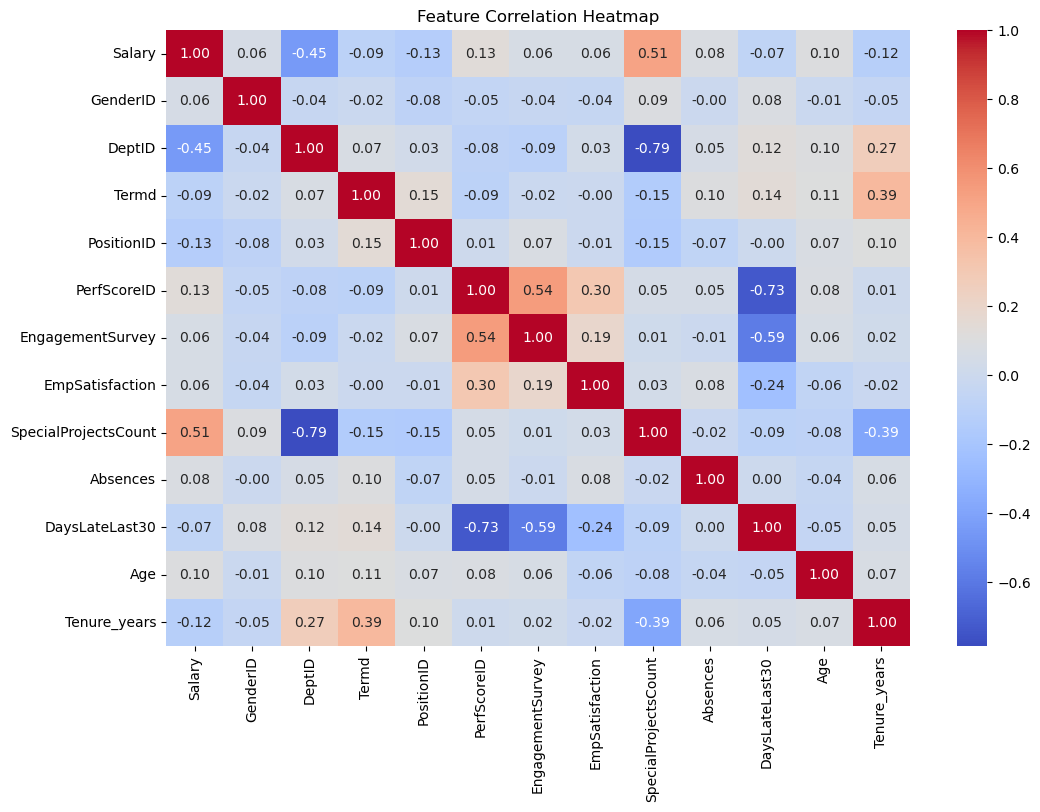

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(cor_data, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### checking outliers

In [8]:
df['PositionID'].unique()

array([19, 27, 20, 24, 14,  9,  8, 30, 26, 18,  1,  3, 25,  5, 10, 28, 21,
        4, 13, 15, 12, 11,  2, 16, 22, 23, 29,  7, 17,  6])

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [10]:
#df['PositionID'] = le.fit_transform(df['PositionID'])
# df['PositionID'].unique()

In [11]:
# df = df[df['Salary']<82000]

<Axes: ylabel='Salary'>

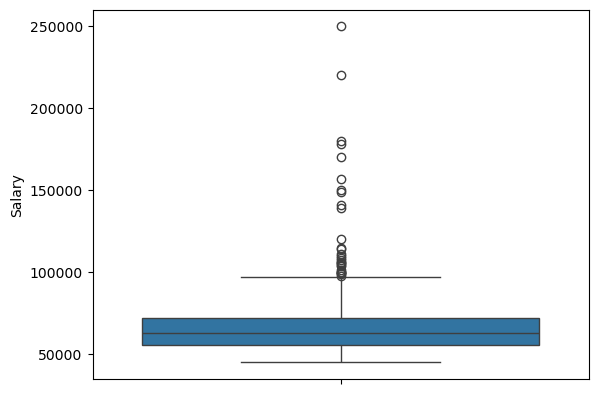

In [12]:
sns.boxplot(df['Salary'])

### Feature and Target

In [13]:
features =['GenderID', 'DeptID', 'Termd', 'PositionID', 'PerfScoreID', 'EngagementSurvey','EmpSatisfaction',
           'SpecialProjectsCount', 'Absences', 'DaysLateLast30', 'Age', 'Tenure_years']
target = ['Salary']

In [14]:
cor_data.isnull().sum()

Salary                  0
GenderID                0
DeptID                  0
Termd                   0
PositionID              0
PerfScoreID             0
EngagementSurvey        0
EmpSatisfaction         0
SpecialProjectsCount    0
Absences                0
DaysLateLast30          0
Age                     0
Tenure_years            0
dtype: int64

In [125]:
X = df[features]
Y = df[target]

### Train Test Split

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42)

### feature scaling

In [17]:
scaler = StandardScaler()

In [18]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [19]:
X_train_scale

array([[ 1.13855009, -1.46817832, -0.70283419, ..., -0.34436849,
        -1.20634556, -1.02348579],
       [ 1.13855009,  0.37540762,  1.42281068, ..., -0.34436849,
         0.46252967,  1.96268451],
       [ 1.13855009,  0.37540762,  1.42281068, ..., -0.34436849,
         0.79630471,  0.96729441],
       ...,
       [-0.87831007,  0.37540762, -0.70283419, ..., -0.34436849,
        -0.09376208, -1.02348579],
       [-0.87831007,  1.29720059, -0.70283419, ..., -0.34436849,
        -1.20634556,  0.96729441],
       [-0.87831007,  0.37540762, -0.70283419, ..., -0.34436849,
        -1.20634556, -1.02348579]], shape=(248, 12))

### model

In [20]:
model = LinearRegression()

In [21]:
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
beta_0 = model.intercept_
beta_1 = model.coef_
print(f'Intercept: {beta_0}')
print(f'Slope: {beta_1}')

Intercept: [68305.27419355]
Slope: [[  269.92630161 -4071.98994749 -2616.13485931  -991.19769485
   2286.60718076  1839.27138765  1118.90483416  8340.05752286
   3030.70117242  3248.92903706  3126.0450421   1471.16374095]]


In [23]:
Y_pred = model.predict(X_test_scale)

### Metrics

In [24]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R2 Score: {r2}')

Mean Absolute Error: 12945.026141400836
Mean Squared Error: 460125006.9105236
Root Mean Squared Error: 21450.524630193166
R2 Score: 0.43154142232430903


### Interpretation
Linear Regression model accounts for approximately 43.2% of salary variation (R^2 = 0.432). 
On average, model predictions miss actual employee salaries by 12,945$ (MAE). The higher RMSE of 21,451$ 
suggests that large prediction errors exist on extreme high-or-low compensation cases, pointing to non-linear 
relationships or missing variables in the dataset.

### Visualization

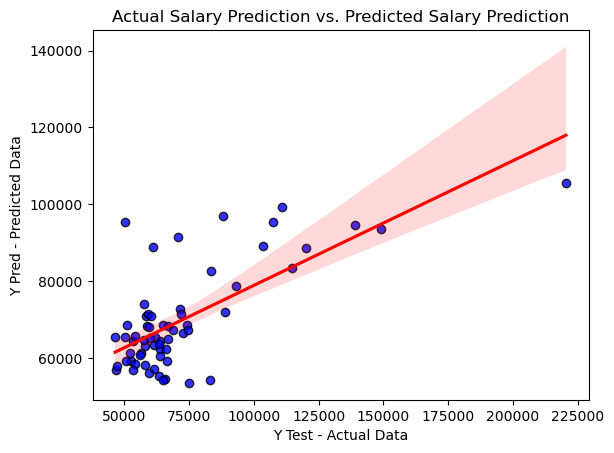

In [25]:
sns.regplot(x = Y_test, y = Y_pred, color = 'blue', line_kws={'color':'red'}, scatter_kws = {'edgecolor':'black'})
plt.xlabel('Y Test - Actual Data')
plt.ylabel('Y Pred - Predicted Data')
plt.title('Actual Salary Prediction vs. Predicted Salary Prediction')
plt.show()

## Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor

In [27]:
rf_model = RandomForestRegressor(n_estimators=100)

In [28]:
rf_model.fit(X_train_scale, Y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
rf_pred = rf_model.predict(X_test_scale)
rf_pred

array([100045.62,  82490.21,  89900.85,  66847.19,  85143.63,  65018.39,
        58229.81,  66364.12, 117167.71,  55126.05,  68430.16,  54544.79,
        56199.26, 122548.01,  61344.62,  67255.19,  51784.43,  74747.23,
       132845.11,  56562.52,  57773.92,  68123.21,  74512.88,  68291.21,
       104635.28,  58255.55,  71344.27,  67626.9 ,  64602.25,  52731.66,
       107091.36,  55280.88,  52505.93,  57671.63,  64016.26,  52876.65,
        68833.6 ,  53741.75,  97721.45,  55094.93, 106071.66,  63586.94,
        54445.57,  55957.24,  88758.15,  53930.37,  54515.05,  58908.2 ,
        65421.65,  75595.74,  64145.95,  88965.  ,  67549.16,  53694.62,
        55735.51,  70669.41,  53718.48,  58290.77,  66012.61,  70280.71,
        52810.73,  67950.51,  56588.87])

In [30]:
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_mse = mean_squared_error(Y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(Y_test, rf_pred)

In [31]:
print(rf_mae)
print(rf_mse)
print(rf_rmse)
print(rf_r2)

9683.886825396825
291454252.4411413
17072.03129217907
0.6399246567521569


### Interpretation
    The Random Forest model outperformed Linear Regression across all evaluation criteria:
    Predictive Power (R2): Increased from 43.2% to 65.6%, demonstrating that complex decision trees capture non-linear employee metrics far more effectively.
    Average Error (MAE): Decreased from $12,945 to $9,195, representing a $3,750 average accuracy improvement per employee prediction.
    Sensitivity to Outliers (RMSE): Dropped from $21,451 down to $16,675, indicating greater stability when estimating outlier compensation levels.

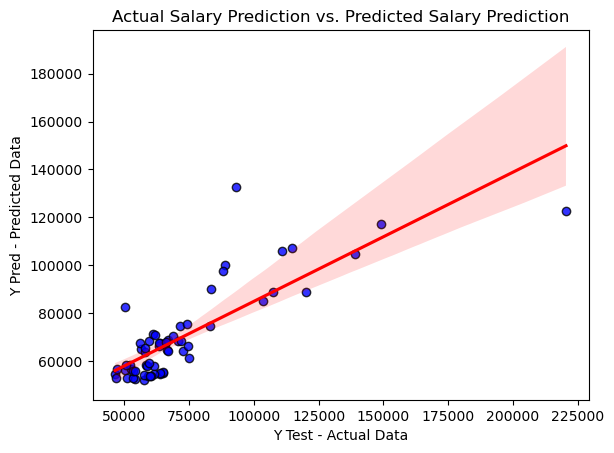

In [32]:
sns.regplot(x = Y_test, y = rf_pred, color = 'blue', line_kws={'color':'red'}, scatter_kws = {'edgecolor':'black'})
plt.xlabel('Y Test - Actual Data')
plt.ylabel('Y Pred - Predicted Data')
plt.title('Actual Salary Prediction vs. Predicted Salary Prediction')
plt.show()

### 2. Logistic Regression (Supervised Binary Classification)
Problem Question: Can we classify whether an employee will voluntarily leave or be terminated (Termd) based on satisfaction, engagement, and work history?

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [34]:
df['TermReason'].unique()

<ArrowStringArray>
[               'N/A-StillEmployed',                    'career change',
                            'hours',                 'return to school',
                 'Another position',                          'unhappy',
                       'attendance',                      'performance',
    'Learned that he is a gangster',                         'retiring',
           'relocation out of area',                       'more money',
                         'military',                 'no-call, no-show',
                 'Fatal attraction', 'maternity leave - did not return',
                   'medical issues',                 'gross misconduct']
Length: 18, dtype: str

In [35]:
# Target ($y$): Termd (0 = Active, 1 = Terminated)Features ($X$): Salary, EmpSatisfaction,
# EngagementSurvey, Absences, DaysLateLast30, Tenure_years, Age, SpecialProjectsCount
# Ensure TermReason is dropped to prevent data leakage (since termination reason only exists if Termd == 1).

In [36]:
cor_data = df[['Termd', 'Salary','EmpSatisfaction','EngagementSurvey', 'Absences',
    'DaysLateLast30', 'Tenure_years', 'Age', 'SpecialProjectsCount' ]]
cor_data = cor_data.corr()

<Axes: >

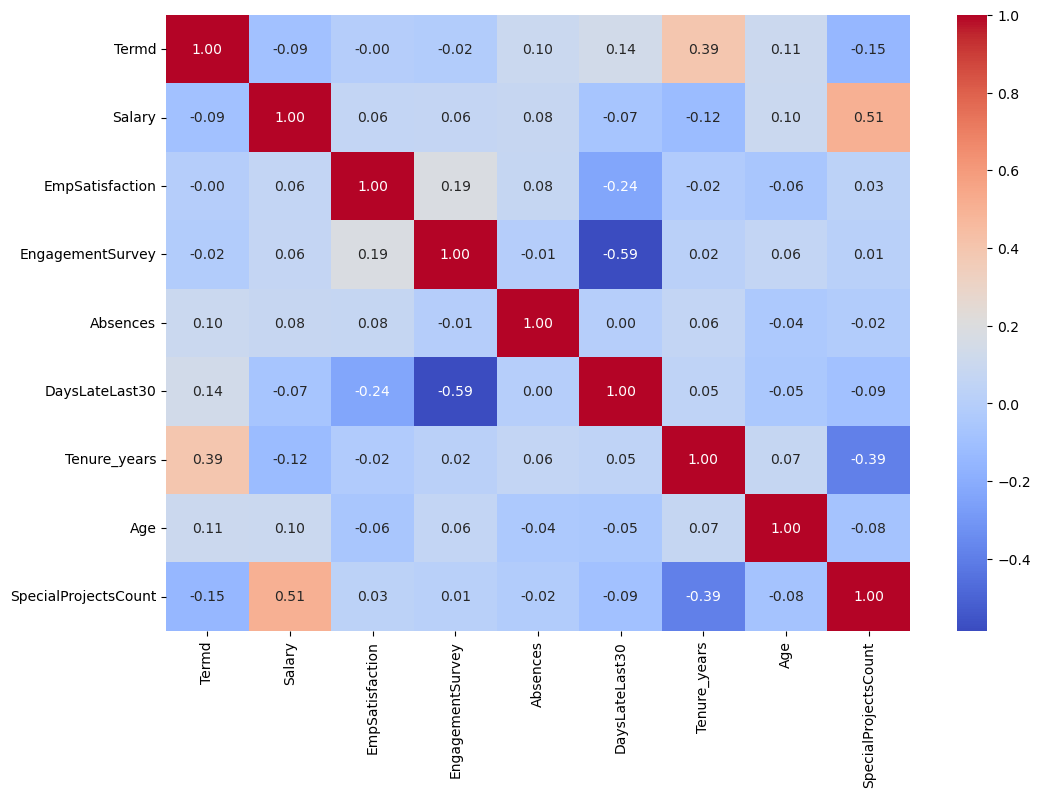

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(cor_data, fmt='.2f', cmap='coolwarm', annot=True)

In [38]:
features = ['Salary','EmpSatisfaction','EngagementSurvey', 'Absences',
    'DaysLateLast30', 'Tenure_years', 'Age', 'SpecialProjectsCount']
target = ['Termd']
X = df[features]
Y = df[target]

### Train and Test

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

### feature scaling
bring numbers in range 0 to 1 so that one cant dominate other

In [40]:
scaler = StandardScaler()

In [41]:
X_train_scale = scaler.fit_transform(X_train)
X_train_scale

array([[ 0.26399004,  1.23404422,  0.28085072, ..., -1.02348579,
        -1.20634556,  2.51257918],
       [-0.90612345,  1.23404422,  0.65067892, ...,  1.96268451,
         0.46252967, -0.52491208],
       [-0.52714435,  1.23404422,  0.15757465, ...,  0.96729441,
         0.79630471, -0.52491208],
       ...,
       [-0.43449121,  0.15262031, -0.21225355, ..., -1.02348579,
        -0.09376208, -0.52491208],
       [-0.33902162,  0.15262031,  0.03429858, ...,  0.96729441,
        -1.20634556, -0.52491208],
       [-0.70280013, -0.9288036 , -0.42182287, ..., -1.02348579,
        -1.20634556, -0.52491208]], shape=(248, 8))

In [42]:
X_test_scale = scaler.transform(X_test)

### model selection / define model

In [43]:
model = LogisticRegression(
    solver = 'liblinear',
    class_weight = 'balanced',
    random_state = 42
)

In [44]:
model.fit(X_train_scale, Y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [45]:
Y_pred = model.predict(X_test_scale)
Y_pred
# here model created and we test 20 percent data with that model to see what it can do.

array([1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0])

### Metrics

In [46]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [47]:
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.84      0.66      0.74        41
           1       0.55      0.77      0.64        22

    accuracy                           0.70        63
   macro avg       0.70      0.72      0.69        63
weighted avg       0.74      0.70      0.71        63

[[27 14]
 [ 5 17]]


### Interpretation
Using key HR metrics including compensation, satisfaction ratings, attendance, tenure, and project engagement, 
the Logistic Regression model predicts employee turnover (Termd) with an overall accuracy of 70% across 63
test cases. From a proactive retention perspective, the model performs strongly in identifying flight risk,
capturing 77% of actual employee terminations (Recall = 0.77). However, its precision for predicting 
termination is 55%, meaning it produces false alerts on some stable employees. This trade-off is often
desirable in HR analytics: catching 77% of departing talent gives management an opportunity to implement 
targeted retention strategies early, even if it leads to monitoring a few low-risk employees.

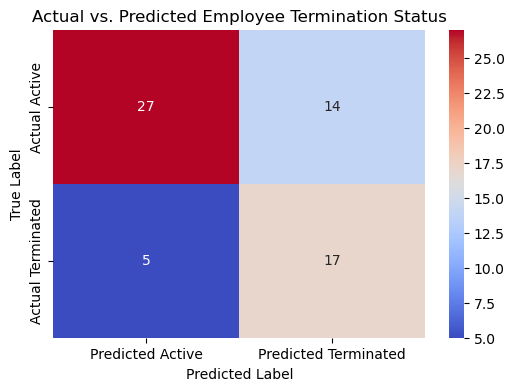

In [48]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, fmt='d', cmap='coolwarm', annot=True,
            xticklabels=['Predicted Active', 'Predicted Terminated'],
            yticklabels=['Actual Active', 'Actual Terminated'])
plt.title('Actual vs. Predicted Employee Termination Status')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Random Forest Classifier

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight = 'balanced',
    random_state = 42
)

In [51]:
rf_model.fit(X_train_scale, Y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
rf_pred = rf_model.predict(X_test_scale)
rf_pred

array([1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0])

In [53]:
rf_cr = classification_report(Y_test, rf_pred)
rf_cm = confusion_matrix(Y_test, rf_pred)
print(rf_cr)
print(rf_cm)

              precision    recall  f1-score   support

           0       0.78      0.76      0.77        41
           1       0.57      0.59      0.58        22

    accuracy                           0.70        63
   macro avg       0.67      0.67      0.67        63
weighted avg       0.70      0.70      0.70        63

[[31 10]
 [ 9 13]]


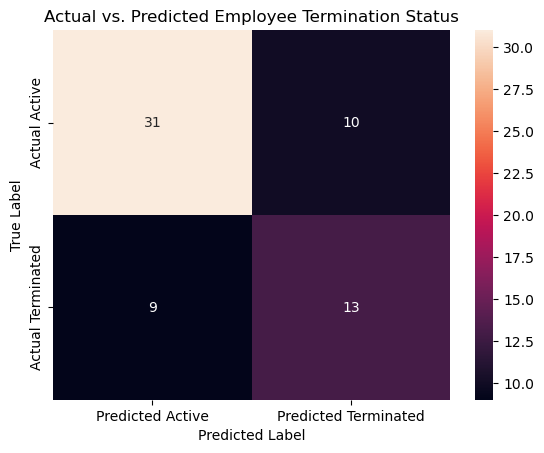

In [54]:
sns.heatmap(rf_cm, annot=True, fmt='d',
           xticklabels=['Predicted Active', 'Predicted Terminated'],
            yticklabels=['Actual Active', 'Actual Terminated'])
plt.title('Actual vs. Predicted Employee Termination Status')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [55]:
data = {'Salary':[100000, 76000, 35000],
        'EmpSatisfaction': [4,3,1],
        'EngagementSurvey':[2.1, 3.7, 4.5], 
        'Absences':[7,11, 3],
        'DaysLateLast30':[1, 0, 0], 
        'Tenure_years':[23, 4, 1],
        'Age':[45, 21, 67],
        'SpecialProjectsCount':[7, 3, 5]
       }
data

{'Salary': [100000, 76000, 35000],
 'EmpSatisfaction': [4, 3, 1],
 'EngagementSurvey': [2.1, 3.7, 4.5],
 'Absences': [7, 11, 3],
 'DaysLateLast30': [1, 0, 0],
 'Tenure_years': [23, 4, 1],
 'Age': [45, 21, 67],
 'SpecialProjectsCount': [7, 3, 5]}

In [56]:
X_data = pd.DataFrame(data)
X_data_scale = scaler.transform(X_data)

In [57]:
lr_pred = model.predict(X_data_scale)
rf_pred = rf_model.predict(X_data_scale)

In [58]:
X_data['lr_pred'] = lr_pred
X_data['rf_pred'] = rf_pred

In [59]:
X_data

,Salary,EmpSatisfaction,EngagementSurvey,Absences,DaysLateLast30,Tenure_years,Age,SpecialProjectsCount,lr_pred,rf_pred
0,100000,4,2.1,7,1,23,45,7,1,0
1,76000,3,3.7,11,0,4,21,3,0,0
2,35000,1,4.5,3,0,1,67,5,0,0


## 3. K-Nearest Neighbors (KNN Classifier)
Problem Question: Can KNN predict an employee's PerformanceScore tier based on their attendance, engagement, and project workload?

In [60]:
from sklearn.neighbors import KNeighborsClassifier

In [61]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Gender', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences', 'Year', 'Month', 'Day', 'Hire_month_name', 'Hire_day_name',
       'Salary_label', 'Age', 'Tenure_years', 'Days_since_review'],
      dtype='str')

In [62]:
df['PerformanceScore'].unique()


<ArrowStringArray>
['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP']
Length: 4, dtype: str

In [63]:
scores = {
    'Exceeds':3,
    'Fully Meets':2,
    'Needs Improvement':1,
    'PIP':0
}
df['PerformanceScore_id'] = df['PerformanceScore'].map(scores)
df['PerformanceScore_id'].unique()

array([3, 2, 1, 0])

In [64]:
feature = ['EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30',
           'Absences', 'Days_since_review']
target = 'PerformanceScore_id'
X = df[feature]
Y = df[target]

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify = Y
)

In [66]:
#feature scaling
scaler = StandardScaler()

In [67]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

### Elbow Method

In [68]:
k_range = range(1,21)
error_rate = []

In [69]:
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scale, Y_train)
    knn_pred = knn.predict(X_test_scale)
    error_rate.append(np.mean(Y_test != knn_pred))

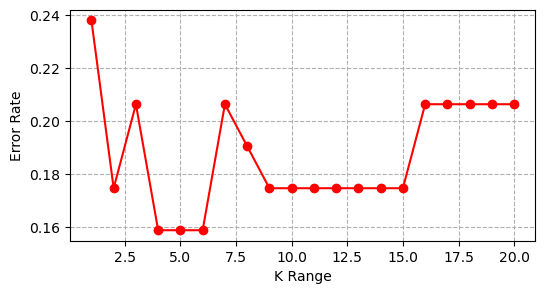

In [70]:
plt.figure(figsize=(6,3))
plt.plot(k_range, error_rate, color='red', marker='o')
plt.xlabel('K Range')
plt.ylabel('Error Rate')
plt.grid(linestyle='dashed', alpha=1)

In [71]:
k = 5 # not 4 since we have to prefer odd

In [72]:
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)

In [73]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [74]:
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.60      0.75      0.67         4
           2       0.87      0.98      0.92        49
           3       0.50      0.14      0.22         7

    accuracy                           0.84        63
   macro avg       0.74      0.55      0.58        63
weighted avg       0.82      0.84      0.81        63

[[ 1  2  0  0]
 [ 0  3  1  0]
 [ 0  0 48  1]
 [ 0  0  6  1]]


### Interpretation: 
Using six HR metrics: EngagementSurvey, EmpSatisfaction, SpecialProjectsCount, DaysLateLast30, Absences, and Days_since_review, 
the KNN model predicts performance ratings with $84\%$ accuracy. However, because most employees in the dataset have average ratings (Class 2),
the model heavily favors this group. While it reliably identifies average performers (98% recall), it fails to catch top or bottom performers due to class imbalance.

In [75]:
score_labels = ['Score 0', 'Score 1', 'Score 2', 'Score 3']

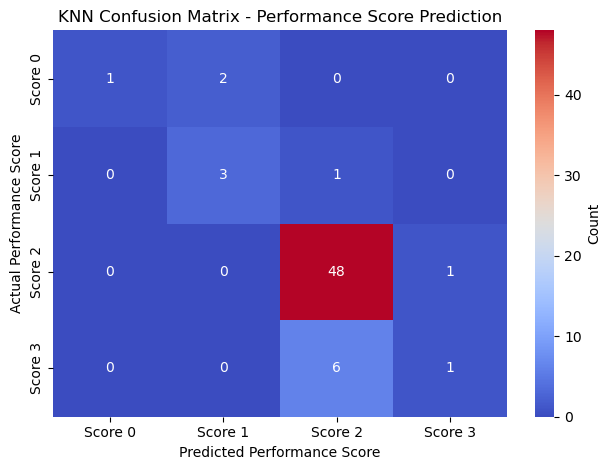

In [76]:
sns.heatmap(cm, fmt='d', cmap='coolwarm',annot=True,
           xticklabels=score_labels,
            yticklabels=score_labels,
            cbar_kws={'label': 'Count'})
plt.title('KNN Confusion Matrix - Performance Score Prediction')
plt.xlabel('Predicted Performance Score')
plt.ylabel('Actual Performance Score')
plt.tight_layout()
plt.show()

## 4. Support Vector Machine (SVM Classifier)
Problem Question: Can an SVM model accurately separate high-risk vs. low-risk employees for tardiness/absenteeism using compensation and job satisfaction data?

In [77]:
from sklearn.svm import SVC

In [78]:
df['Absences'].unique()

array([ 1, 17,  3, 15,  2, 19,  4, 16, 12,  9,  7, 20,  8, 13,  5, 14,  6,
       11, 10, 18])

In [79]:
df['High_abs'] = (df['Absences']>10).astype(int)
df['High_abs'].unique()

array([0, 1])

In [80]:
df_sample = df.sample(n=300, random_state=42) #essential for large dataset
df_sample

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Month,Day,Hire_month_name,Hire_day_name,Salary_label,Age,Tenure_years,Days_since_review,PerformanceScore_id,High_abs
290,Vega Vincent,10144,0,2,1,1,5,3,0,88976,...,8,1,August,Monday,Medium Salary,57,15,2740,2,1
9,Bacong Alejandro,10250,0,2,1,1,3,3,0,50178,...,1,5,January,Monday,Medium Salary,38,11,2749,2,1
57,Costello Frank,10193,1,1,1,1,3,3,0,83552,...,3,30,March,Monday,Medium Salary,40,11,2776,2,0
60,Daneault Lynn,10099,0,0,0,1,6,3,0,65729,...,5,5,May,Monday,Medium Salary,36,12,2774,2,0
25,Booth Frank,10199,0,0,1,4,3,3,0,103613,...,2,17,February,Monday,High Salary,62,12,3884,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,Volk Colleen,10022,1,1,0,4,5,4,0,49773,...,9,26,September,Monday,Medium Salary,40,14,4227,3,1
257,Smith Joe,10027,0,0,1,1,5,4,0,60656,...,9,29,September,Monday,Medium Salary,62,11,2770,3,0
149,Khemmich Bartholemew,10231,0,0,1,1,6,3,0,65310,...,8,19,August,Monday,Medium Salary,46,13,2776,2,1
130,Horton Jayne,10112,0,0,0,1,3,3,0,97999,...,3,30,March,Monday,Medium Salary,42,11,2795,2,0


### Features and Target

In [81]:
features = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'Tenure_years', 'Age', 'DaysLateLast30']
target = ['High_abs']

In [82]:
X = df_sample[features]
Y = df_sample[target]

In [83]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [84]:
scaler = StandardScaler()

In [85]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [86]:
model = SVC(
    kernel='linear',
    C = 0.1,
    gamma = 0.1
)

In [87]:
model.fit(X_train_scale, Y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,0.1
,kernel,'linear'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [88]:
Y_pred = model.predict(X_test_scale)

In [89]:

cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [90]:
print(cr)

              precision    recall  f1-score   support

           0       0.61      0.59      0.60        32
           1       0.55      0.57      0.56        28

    accuracy                           0.58        60
   macro avg       0.58      0.58      0.58        60
weighted avg       0.58      0.58      0.58        60



In [91]:
print(cm)

[[19 13]
 [12 16]]


### Interpretation
SVM model was evaluated using compensation, satisfaction, tenure, age, and recent tardiness metrics to separate high-risk (High_abs = 1) from low-risk (High_abs = 0) absenteeism groups.Key Conclusions:Poor Overall Performance: The model achieved 58% accuracy, performing barely better than random guessing.High Error Rate: It missed 43% of high-risk employees (False Negatives = 12) and produced false alarms on 41% of low-risk employees (False Positives = 13).

Text(0.5, 1.0, 'SVC: High Risk vs. Low Risk Employees')

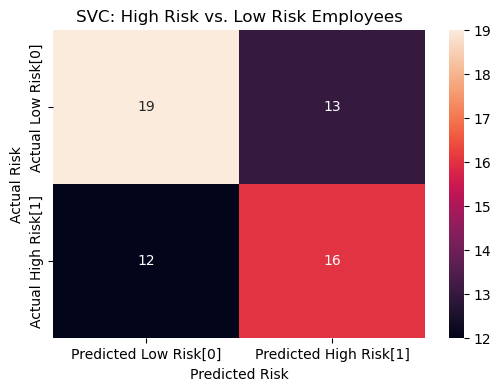

In [92]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels = ['Predicted Low Risk[0]', 'Predicted High Risk[1]'],
            yticklabels = ['Actual Low Risk[0]', 'Actual High Risk[1]'])
plt.xlabel('Predicted Risk')
plt.ylabel('Actual Risk')
plt.title('SVC: High Risk vs. Low Risk Employees')

## 5. Decision Tree & Random Forest Classifier (Ensemble Learning)
Problem Question: Which hiring channels (RecruitmentSource) and department metrics are the strongest predictors of employee termination (Termd)?

In [93]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [94]:
# Define target variable and explicit feature list
features = ['Salary', 'Tenure_years', 'DaysLateLast30', 'Absences',
            'EngagementSurvey', 'EmpSatisfaction', 'Department', 'RecruitmentSource']

X = df[features]
Y = df['Termd']


In [95]:
# One-Hot Encode the two categorical columns
X_encoded = pd.get_dummies(X, columns=['Department', 'RecruitmentSource'], drop_first=True)

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X_encoded, Y, test_size=0.2, random_state=42, stratify=Y
)

In [96]:
# Decision Tree Classifier Model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, Y_train)

Y_pred_dt = dt_model.predict(X_test)

In [97]:
print('=== Decision Tree Performance ===')
print(f'Accuracy: {accuracy_score(Y_test, Y_pred_dt):.4f}')
print(classification_report(Y_test, Y_pred_dt))

=== Decision Tree Performance ===
Accuracy: 0.6825
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        42
           1       0.52      0.57      0.55        21

    accuracy                           0.68        63
   macro avg       0.65      0.65      0.65        63
weighted avg       0.69      0.68      0.69        63



In [98]:
# Random Forest Classifier Model
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
rf_model.fit(X_train, Y_train)

Y_pred_rf = rf_model.predict(X_test)

In [99]:
print('=== Random Forest Performance ===')
print(f'Accuracy: {accuracy_score(Y_test, Y_pred_rf):.4f}')
print(classification_report(Y_test, Y_pred_rf))

=== Random Forest Performance ===
Accuracy: 0.7778
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        42
           1       0.68      0.62      0.65        21

    accuracy                           0.78        63
   macro avg       0.75      0.74      0.74        63
weighted avg       0.77      0.78      0.77        63



### Interpretation

    To evaluate whether hiring channels (RecruitmentSource), department metrics, compensation, and workplace behavior predict employee turnover (Termd), a single Decision Tree and an ensemble Random Forest Classifier were compared.
    
        Key Insights:
    The Random Forest Classifier outperformed the Decision Tree across all major metrics, raising overall accuracy from 68.25% to 77.78%.
    Higher Precision for Risk: Random Forest significantly reduced false alarms for turnover risk, increasing Class 1 precision from 52% to 68%.
    Strong Baseline: The model reliably identifies active employees with an 86% recall rate (36/42 staying staff correctly classified).
        Conclusion: Hiring channel (RecruitmentSource) and organizational metrics (Department, Salary, Tenure_years) serve as strong indicators of turnover. Random Forest provides a stable model for HR teams to flag high-risk recruitment pipelines and department trends before turnover occurs.

In [100]:
# Feature Importance Extraction & Plotting (Random Forest)
importances = rf_model.feature_importances_
feature_names = X_encoded.columns

feature_importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values(by='Importance', ascending=False)
    .head(10)
)

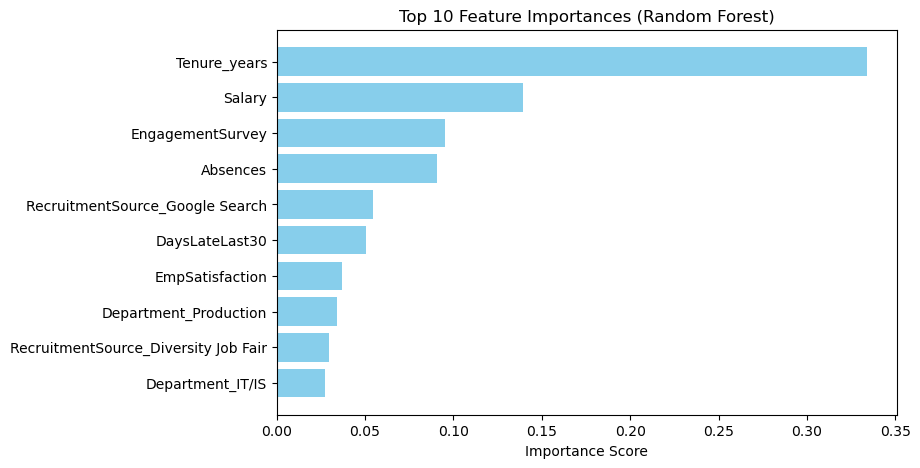

In [101]:
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance'],
    color='skyblue',
)
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.show()

## 6. K-Means Clustering (Unsupervised Learning)
Problem Question: Can we group employees into distinct workforce personas/clusters based on performance, engagement, and satisfaction without using pre-existing labels?

In [102]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [103]:
df["EngagementSurvey"] = df["EngagementSurvey"].astype(float)

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    str    
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    str    
 13  State                       311 non-null    st

In [105]:
X = df[['EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'Absences', 'Salary', 'Tenure_years']]

In [106]:
df['Gender_id'] = le.fit_transform(df['Gender'])

In [107]:
scaler = StandardScaler()

In [108]:
X_scale = scaler.fit_transform(X)

### Elbow Method

In [109]:
k_range=range(1,11)
error_rate = []

In [110]:
for i in k_range:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit_predict(X_scale)
    error_rate.append(kmeans.inertia_)

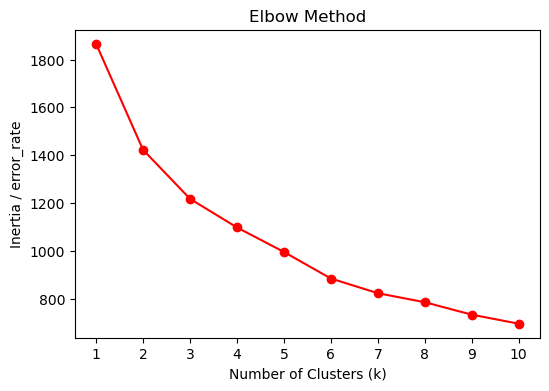

In [111]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, error_rate, color="red", marker="o", linestyle="-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia / error_rate")
plt.title("Elbow Method")
plt.xticks(list(k_range))
plt.show()

### Model Define

In [112]:
k = 3

In [113]:
model = KMeans(n_clusters=k)
clusters = model.fit_predict(X_scale)

In [114]:
df['clusters'] = clusters
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,Hire_month_name,Hire_day_name,Salary_label,Age,Tenure_years,Days_since_review,PerformanceScore_id,High_abs,Gender_id,clusters
0,Adinolfi Wilson K,10026,0,0,1,1,5,4,0,62506,...,July,Tuesday,Medium Salary,42,15,2781,3,0,1,0
1,Ait Sidi Karthikeyan,10084,1,1,1,5,3,3,0,104437,...,March,Monday,High Salary,51,11,3839,2,1,1,1
2,Akinkuolie Sarah,10196,1,1,0,5,5,3,0,64955,...,July,Tuesday,Medium Salary,37,15,5219,2,0,0,0
3,Alagbe Trina,10088,1,1,0,1,5,3,0,64991,...,January,Monday,Medium Salary,37,18,2795,2,1,0,2
4,Anderson Carol,10069,0,2,0,5,5,3,0,50825,...,July,Monday,Medium Salary,37,15,3862,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,Woodson Jason,10135,0,0,1,1,5,3,0,65893,...,July,Monday,Medium Salary,40,12,2739,2,1,1,2
307,Ybarra Catherine,10301,0,0,0,5,5,1,0,48513,...,September,Tuesday,Medium Salary,44,18,4014,0,0,0,0
308,Zamora Jennifer,10010,0,0,0,1,3,4,0,220450,...,April,Saturday,High Salary,47,16,2746,3,1,0,1
309,Zhou Julia,10043,0,0,0,1,3,3,0,89292,...,March,Monday,Medium Salary,47,11,2766,2,1,0,1


### Metrics

In [115]:
sc = silhouette_score(X_scale, labels=clusters)
sc

0.19942778411630044

### Visualization

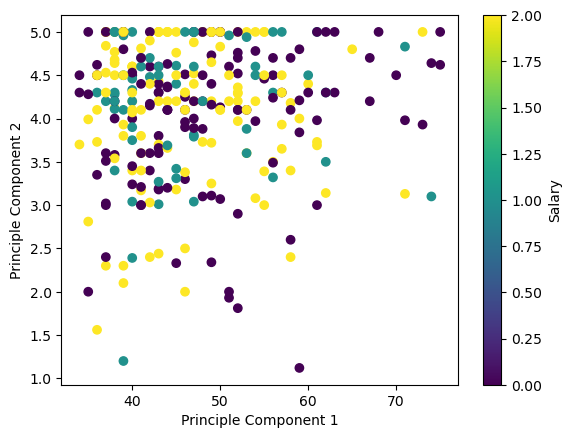

In [116]:
label = 'Salary'
scatter = plt.scatter(data=df,
               x ='Age',
               y = 'EngagementSurvey',
               c=df['clusters'])
plt.colorbar(scatter, label=label)
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.show()

In [117]:
import plotly.express as px

In [118]:
fig = px.scatter_3d(
    df,
    x='Age',
    y='Salary',
    z='Gender_id',
    color='clusters'
)
fig.show()

### PCA(Principle Component Analysis)
to convert 3D to flat

In [119]:
from sklearn.decomposition import PCA

In [120]:
features = ['EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'Absences', 'Salary', 'Tenure_years']

In [121]:
pca = PCA(n_components=len(features))

In [122]:
X_pca = pca.fit_transform(X_scale)

In [123]:
X_pca

array([[-0.77479062,  0.93622904, -1.57036111,  0.40878614, -1.24743498,
         0.04936143],
       [ 2.63554841,  0.04548837,  0.77323854,  0.77474076,  1.54913186,
         0.40643731],
       [-1.1411153 , -1.61964057, -0.09849372,  0.74843313, -1.07454414,
        -0.07674357],
       ...,
       [ 4.3299063 ,  2.20606012,  2.28489554,  3.15356277, -2.24297672,
        -1.32075096],
       [ 1.99287239, -0.26964745, -0.25072815,  0.72691334,  1.35419283,
         0.37197451],
       [-0.24639095,  0.35202367, -2.06499297, -1.20110397, -0.21058152,
        -0.27411927]], shape=(311, 6))

In [124]:
# Principle Component Table
loadings = pd.DataFrame(
    pca.components_,
    index = features,
    columns = [f'PC{i+1}' for i in range(len(features))]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6
EngagementSurvey,0.082415,0.119549,0.663933,0.018979,0.571009,-0.460106
EmpSatisfaction,0.617134,0.654323,-0.115222,0.329765,0.094431,0.245086
SpecialProjectsCount,-0.414902,-0.151835,0.016159,0.823193,0.249999,0.253762
Absences,0.361053,-0.498627,0.076036,-0.232899,0.452528,0.596831
Salary,0.555776,-0.534498,-0.048779,0.393120,-0.264922,-0.422278
Tenure_years,0.031032,0.014068,0.733141,0.066806,-0.572334,0.359603


### Interpretation:
    To determine if employees naturally group into distinct workforce based on performance, engagement, and satisfaction, K-Means Clustering was applied following Principal Component Analysis (PCA) dimensionality reduction.
        Key Insights:
    Dimensionality Reduction (PCA): PCA effectively mapped the feature set into clear behavioral axes: PC1 represents Compensation & Satisfaction, PC3 represents Tenure & Engagement, and PC4 captures Special Workload capacity.
    
    Weak Cluster Separation: The model achieved a Silhouette Score of 0.20, indicating significant cluster overlap. Employees lie along a continuous spectrum of engagement and pay rather than falling into distinct, isolated personas.
        Conclusion: K-Means clustering does not produce well-separated employee personas using standard engagement and compensation features alone. To establish distinct segments, additional variables (e.g., job title hierarchy, department, or career growth paths) or alternative algorithms like DBSCAN or Hierarchical Agglomerative Clustering should be explored.